# Netflix catalog analysis

`netflix_titles.csv` has Netflix's movies and TV shows, with genres, country, date added,
age rating, duration, and so on. I'm only looking at movies here (`type == 'Movie'`) -
TV shows don't have a duration in minutes, so they don't fit the numeric analysis below.

Rough order: clean the data (1-2), build a couple of extra features (3), poke around (4),
run some actual statistics on it (5), then charts and a writeup (6-7).

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, spearmanr
import matplotlib.pyplot as plt

## 1. Load and take a first look

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


Let's check how many rows are missing a director, separately for movies and TV shows:

In [4]:
df.groupby('type')['director'].apply(lambda x: x.isna().sum())

type
Movie       188
TV Show    2446
Name: director, dtype: int64

In [5]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

## 2. Cleaning up the movies

Filtering down to movies, then fixing what's broken: some rating/duration values are
swapped, a bunch of fields are missing, and `date_added` is a string instead of a date.

In [6]:
df_movies = df[df['type'] == 'Movie'].copy()
print(df_movies.shape)
df_movies.head()

(6131, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


Some rows have the duration sitting in the `rating` column instead of the rating -
things like `"90 min"` where a rating should be. Classic data entry mess:

In [7]:
df_movies['rating'].unique()

<StringArray>
[   'PG-13',       'PG',    'TV-MA',    'TV-PG',    'TV-14',     'TV-Y',
        'R',     'TV-G',    'TV-Y7',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

In [8]:
rows_misplaced_duration = df_movies[df_movies['rating'].str.contains(r'\bmin\b', na=False, regex=True)]
rows_misplaced_duration

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [9]:
# move the duration out of rating into duration, and blank out rating for those rows
mask = df_movies['rating'].str.contains('min', na=False)
df_movies.loc[mask, 'duration'] = df_movies.loc[mask, 'rating']
df_movies.loc[mask, 'rating'] = pd.NA

df_movies['rating'].unique()

<StringArray>
[   'PG-13',       'PG',    'TV-MA',    'TV-PG',    'TV-14',     'TV-Y',
        'R',     'TV-G',    'TV-Y7',        'G',    'NC-17',        nan,
       'NR', 'TV-Y7-FV',       'UR']
Length: 15, dtype: str

Now `director`/`cast` get a placeholder for the missing values, and `date_added` becomes a real date:

In [10]:
df_movies['director'] = df_movies['director'].fillna('Unknown')
df_movies['cast'] = df_movies['cast'].fillna('Unknown')
df_movies['date_added'] = pd.to_datetime(df_movies['date_added'])

df_movies.info()

<class 'pandas.DataFrame'>
Index: 6131 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       6131 non-null   str           
 1   type          6131 non-null   str           
 2   title         6131 non-null   str           
 3   director      6131 non-null   str           
 4   cast          6131 non-null   str           
 5   country       5691 non-null   str           
 6   date_added    6131 non-null   datetime64[us]
 7   release_year  6131 non-null   int64         
 8   rating        6126 non-null   str           
 9   duration      6131 non-null   str           
 10  listed_in     6131 non-null   str           
 11  description   6131 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 622.7 KB


Which genres are missing a country most often:

In [11]:
df_movies[df_movies['country'].isna()]['listed_in'].value_counts()

listed_in
Children & Family Movies                                         70
Stand-Up Comedy                                                  31
Dramas, International Movies                                     25
Movies                                                           23
Documentaries, International Movies                              21
                                                                 ..
Dramas, Thrillers                                                 1
Children & Family Movies, Documentaries, International Movies     1
Action & Adventure, Comedies, Independent Movies                  1
Comedies, Horror Movies, International Movies                     1
Comedies, Horror Movies, Sci-Fi & Fantasy                         1
Name: count, Length: 66, dtype: int64

## 3. Feature engineering

A few extra columns for the analysis:
- `month_added`, `year_added` - when the title was added to Netflix
- `delay_years` - years between release and being added to Netflix
- `duration_min` - duration as a number, in minutes
- `primary_genre`, `primary_country` - first genre/country listed
- `rating_ordinal` - rating as a number, from least to most restrictive

In [12]:
date_added_pos = df_movies.columns.get_loc('date_added')
df_movies.insert(date_added_pos + 1, 'year_added', df_movies['date_added'].dt.year)
df_movies.insert(date_added_pos + 1, 'month_added', df_movies['date_added'].dt.month)

release_year_pos = df_movies.columns.get_loc('release_year')
df_movies.insert(release_year_pos + 1, 'delay_years', df_movies['year_added'] - df_movies['release_year'])

df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)

df_movies['primary_genre'] = df_movies['listed_in'].str.split(', ').str[0]
df_movies['primary_country'] = df_movies['country'].str.split(', ').str[0]

rating_order = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'TV-G', 'PG', 'TV-PG',
                'PG-13', 'TV-14', 'R', 'NC-17', 'TV-MA']
df_movies['rating_ordinal'] = df_movies['rating'].map({r: i for i, r in enumerate(rating_order)})

df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,delay_years,rating,duration,listed_in,description,duration_min,primary_genre,primary_country,rating_ordinal
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,9,2021,2020,1,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,Documentaries,United States,7.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,Children & Family Movies,NaN,5.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,28,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,Dramas,United States,11.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,Comedies,United States,7.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127.0,Dramas,Germany,11.0


## 4. Exploring the data

Genres, countries, and how many movies got added each year.

In [13]:
categories_count = df_movies['listed_in'].str.strip().str.split(', ').explode().value_counts()
categories_count

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Anime Features                71
Cult Movies                   71
Faith & Spirituality          65
Movies                        57
Name: count, dtype: int64

In [14]:
categories_count.tail(10)

listed_in
Horror Movies           357
Stand-Up Comedy         343
Sci-Fi & Fantasy        243
Sports Movies           219
Classic Movies          116
LGBTQ Movies            102
Anime Features           71
Cult Movies              71
Faith & Spirituality     65
Movies                   57
Name: count, dtype: int64

In [15]:
top_countries = df_movies['country'].dropna().str.split(', ').explode().value_counts()
top_countries.head(10)

country
United States     2751
India              962
United Kingdom     532
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: count, dtype: int64

In [16]:
df_movies.groupby('year_added').size()

year_added
2008       1
2009       2
2010       1
2011      13
2012       3
2013       6
2014      19
2015      56
2016     253
2017     839
2018    1237
2019    1424
2020    1284
2021     993
dtype: int64

In [17]:
print('Rating')
print(df_movies['rating'].value_counts())
print('\nCategories (top 5)')
print(df_movies['listed_in'].str.split(', ').explode().value_counts().head(5))
print('\nCountries (top 5)')
print(df_movies['country'].dropna().str.split(', ').explode().value_counts().head(5))

Rating
rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

Categories (top 5)
listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

Countries (top 5)
country
United States     2751
India              962
United Kingdom     532
Canada             319
France             303
Name: count, dtype: int64


## 5. Statistics

Two things worth checking:
1. Does the rating relate to genre, country, or content type? (chi-square test and Cramér's V)
2. Does the rating relate to release year or duration? (Spearman correlation, since
   `rating_ordinal` is ordinal)

First attempt: cross-tab `rating` against `listed_in` as-is. The problem is `listed_in` stores
genre combinations separated by commas, so the table ends up sparse and not very useful:

In [18]:
contingency_raw = pd.crosstab(df_movies['listed_in'], df_movies['rating'])
chi2, p, dof, expected = chi2_contingency(contingency_raw)
print(f'Genre combinations as-is: p-value = {p:.4f}, table shape = {contingency_raw.shape}')

Genre combinations as-is: p-value = 0.0000, table shape = (278, 14)


Splitting `listed_in` into individual genres (explode) and running it again:

In [19]:
exploded_genre = df_movies['listed_in'].str.split(', ').explode()
exploded = df_movies[['rating']].join(exploded_genre)

contingency_exploded = pd.crosstab(exploded['listed_in'].values, exploded['rating'].values)
chi2, p, dof, expected = chi2_contingency(contingency_exploded)
print(f'Individual genres: p-value = {p:.4f}, table shape = {contingency_exploded.shape}')

Individual genres: p-value = 0.0000, table shape = (20, 14)


Still sparse, which, honestly, was predictable - 20-ish genres times 14 ratings is a lot
of nearly-empty cells. From here on I'll use `primary_genre`/`primary_country` (one value per
movie) and wrap the Cramér's V calculation in a function so I'm not copy-pasting it three times:

In [20]:
def cramers_v(col1, col2):
    contingency = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cols = ['rating', 'primary_genre', 'primary_country']
matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        matrix.loc[col1, col2] = cramers_v(df_movies[col1].dropna(), df_movies[col2].dropna())

matrix.round(3)

,rating,primary_genre,primary_country
rating,1.000,0.260,0.207
primary_genre,0.260,1.000,0.191
primary_country,0.207,0.191,1.000


Now the rating against release year and duration:

In [21]:
corr, p = spearmanr(
    df_movies['rating_ordinal'].dropna(),
    df_movies.loc[df_movies['rating_ordinal'].notna(), 'release_year'],
)
print(f'Rating vs release year: Spearman r = {corr:.3f}, p-value = {p:.4f}')

Rating vs release year: Spearman r = 0.164, p-value = 0.0000


In [22]:
corr, p = spearmanr(
    df_movies['rating_ordinal'].dropna(),
    df_movies.loc[df_movies['rating_ordinal'].notna(), 'duration_min'],
)
print(f'Rating vs duration: Spearman r = {corr:.3f}, p-value = {p:.4f}')

Rating vs duration: Spearman r = 0.049, p-value = 0.0001


## 6. Charts

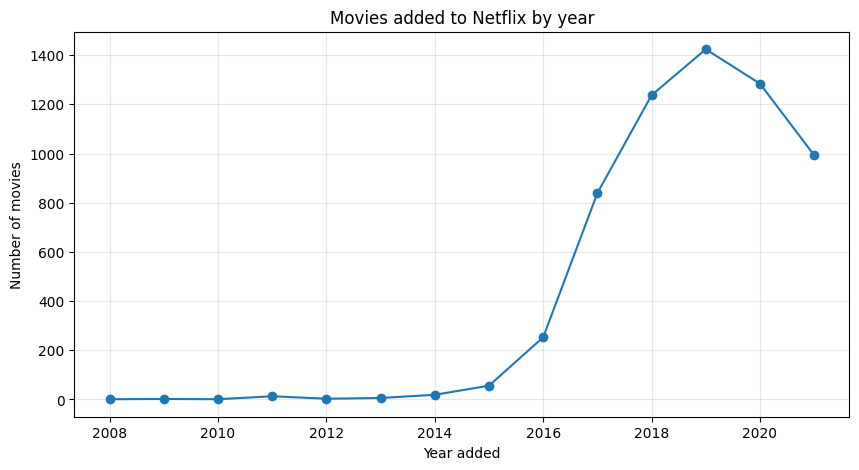

In [23]:
yearly_counts = df_movies.groupby('year_added').size()

plt.figure(figsize=(10, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title('Movies added to Netflix by year')
plt.xlabel('Year added')
plt.ylabel('Number of movies')
plt.grid(True, alpha=0.3)
plt.show()

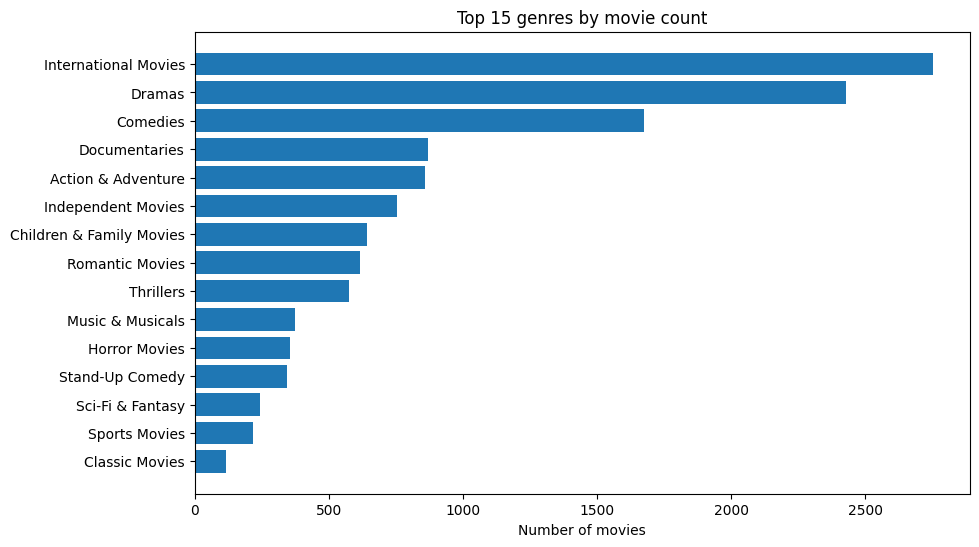

In [24]:
genre_counts = df_movies['listed_in'].str.split(', ').explode().value_counts().head(15)

plt.figure(figsize=(10, 6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title('Top 15 genres by movie count')
plt.xlabel('Number of movies')
plt.show()

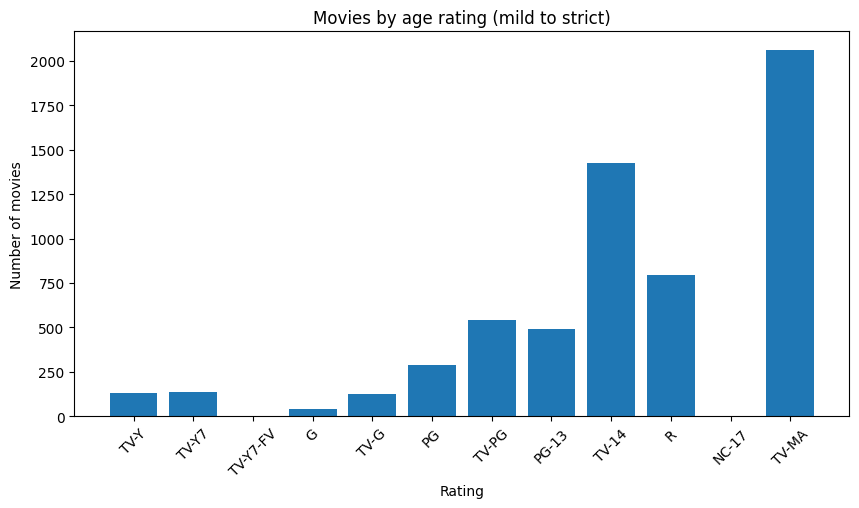

In [25]:
rating_counts_ordered = df_movies['rating'].value_counts().reindex(rating_order)

plt.figure(figsize=(10, 5))
plt.bar(rating_counts_ordered.index, rating_counts_ordered.values)
plt.title('Movies by age rating (mild to strict)')
plt.xlabel('Rating')
plt.ylabel('Number of movies')
plt.xticks(rotation=45)
plt.show()

## 7. What I found

- Movies added to Netflix grew every year through 2019, peaking at 1424 titles. Then it
  dropped: 1284 in 2020, 993 in 2021 - though 2021 is a partial year, the data stops in
  September, so that last number is misleading on its own.
- International Movies (2752), Dramas (2427), and Comedies (1674) dominate the catalog.
  Faith & Spirituality and the generic "Movies" tag barely register, around 57-65 titles each.
- Rating is statistically related to genre and country (p < 0.0001 on the chi-square test),
  but Cramér's V puts the actual strength at only about 0.26 for rating/genre and 0.21 for
  rating/country. With 6000+ rows, almost anything comes out "significant" - the V is the
  number that actually tells you whether the relationship is worth caring about, and here it
  says: not much.
- Same story with release year: Spearman r is about 0.16 (p < 0.0001), so newer movies trend
  very slightly toward stricter ratings, but it's a weak trend, not a rule.
- Duration and rating are essentially uncorrelated (r ≈ 0.05). The p-value is small because
  the sample is large, not because the effect means anything.